In [16]:
bins<-c(1,2,4,5,4,3,1)

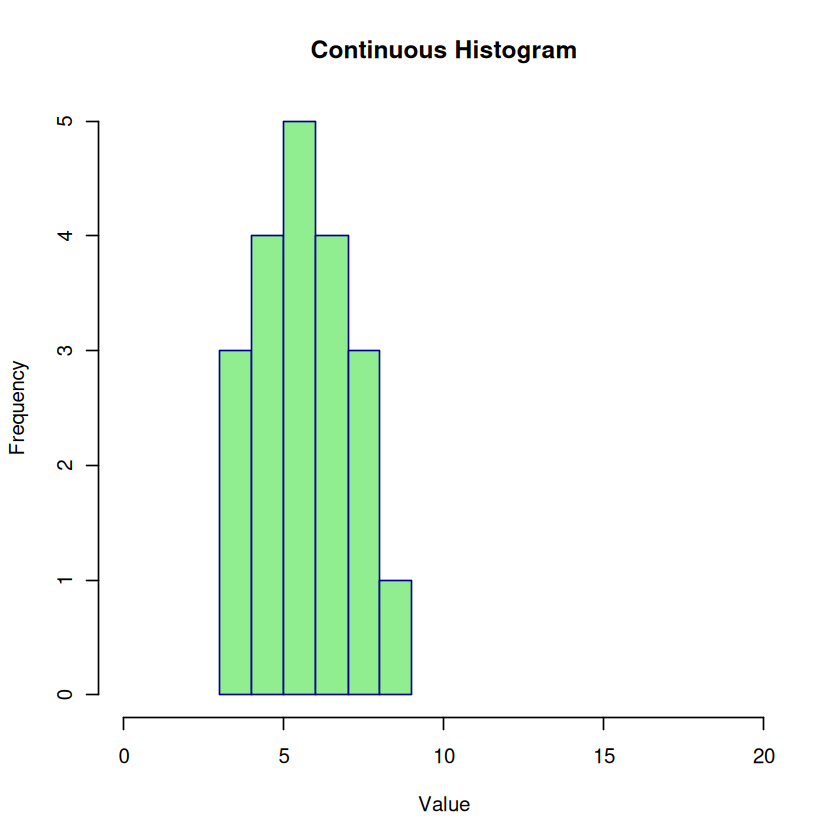

In [24]:
# Example raw data
data <- c(3,4,4,5,5,5,5,6,6,6,6,6,7,7,7,7,8,8,8,9)

# Create a continuous histogram with hist()
hist(data, col = "lightgreen", 
     xlab = "Value", ylab = "Frequency", 
     main = "Continuous Histogram", border = "darkblue",xlim=c(0,20))

In [17]:
right<-c(3,4,5,6,7,8,9)

In [25]:
# Install splines2 package (if you don't have it)
install.packages("splines2")

# Load the splines2 package
library(splines2)

Installing package into ‘/home/sm1mkr/R/x86_64-pc-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)



In [27]:
# Values representing the bin edges (right edges of bins)
vals <- c(3, 4, 5, 6, 7, 8)

# Cumulative probabilities for these bins
cumsums <- c(0.05, 0.15, 0.35, 0.6, 0.8, 0.95)

In [47]:


# Define the limits (assuming they are 0 and 20 as you mentioned)
lower_limit <- 0
upper_limit <- 10

# Adjust the cumulative probabilities to account for the limits
extended_vals <- c(lower_limit, vals, upper_limit)
extended_cumsums <- c(0, cumsums, 1)

# Fit the B-spline to the extended CDF data
cdf_bspline_fit <- lm(extended_cumsums ~ bSpline(extended_vals, degree = 3))

# Show the summary of the fitted B-spline model
summary(cdf_bspline_fit)


Call:
lm(formula = extended_cumsums ~ bSpline(extended_vals, degree = 3))

Residuals:
        1         2         3         4         5         6         7         8 
-0.005079  0.039795 -0.026340 -0.029586  0.007117  0.010831  0.008616 -0.005354 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          0.005079   0.029217   0.174   0.8704    
bSpline(extended_vals, degree = 3)1 -0.585778   0.084812  -6.907   0.0023 ** 
bSpline(extended_vals, degree = 3)2  1.251039   0.070096  17.847 5.79e-05 ***
bSpline(extended_vals, degree = 3)3  1.000275   0.041362  24.184 1.73e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02937 on 4 degrees of freedom
Multiple R-squared:  0.997,	Adjusted R-squared:  0.9947 
F-statistic: 442.7 on 3 and 4 DF,  p-value: 1.689e-05



Call:
lm(formula = extended_cumsums ~ bSpline(extended_vals, degree = 3))

Residuals:
        1         2         3         4         5         6         7         8 
-0.005079  0.039795 -0.026340 -0.029586  0.007117  0.010831  0.008616 -0.005354 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          0.005079   0.029217   0.174   0.8704    
bSpline(extended_vals, degree = 3)1 -0.585778   0.084812  -6.907   0.0023 ** 
bSpline(extended_vals, degree = 3)2  1.251039   0.070096  17.847 5.79e-05 ***
bSpline(extended_vals, degree = 3)3  1.000275   0.041362  24.184 1.73e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02937 on 4 degrees of freedom
Multiple R-squared:  0.997,	Adjusted R-squared:  0.9947 
F-statistic: 442.7 on 3 and 4 DF,  p-value: 1.689e-05


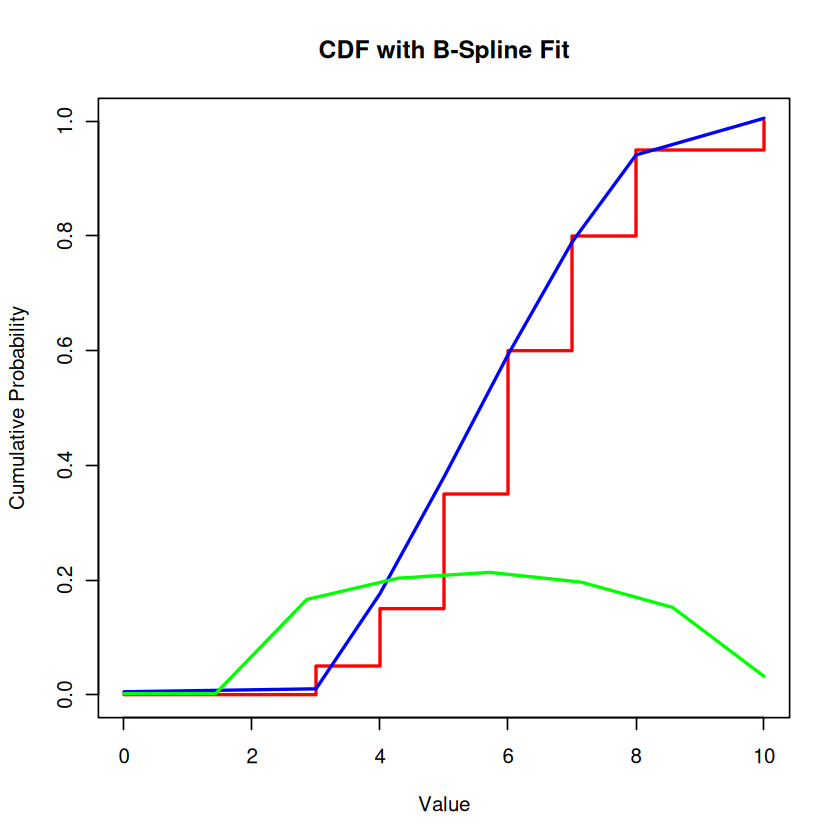

In [78]:
# Values representing the bin edges (right edges of bins)
vals <- c(3, 4, 5, 6, 7, 8)

# Cumulative probabilities for these bins
cumsums <- c(0.05, 0.15, 0.35, 0.6, 0.8, 0.95)

# Define the limits
lower_limit <- 0
upper_limit <- 10

# Adjust the cumulative probabilities to account for the limits
extended_vals <- c(lower_limit, vals, upper_limit)
extended_cumsums <- c(0, cumsums, 1)

# Fit the B-spline to the extended CDF data (force the spline to meet at limits)
cdf_bspline_fit <- lm(extended_cumsums ~ bSpline(extended_vals, degree = 3))

# Show the summary of the fitted B-spline model
summary(cdf_bspline_fit)

# Create the plot for cumulative distribution function
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 2, 
     xlim = c(lower_limit, upper_limit), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")

# Add the B-spline fit to the plot
lines(extended_vals, predict(cdf_bspline_fit), col = "blue", lwd = 2)

# Optionally, plot the derivative to see the PDF
# Calculate the derivative of the fitted CDF (PDF)
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit)) / diff(extended_vals)

# Check the integral of the PDF (it should be close to 1)
integral_check <- sum(cdf_bspline_derivative * diff(extended_vals))
cat("Integral of the PDF: ", integral_check, "\n")

# Normalize the PDF to ensure it integrates to 1
cdf_bspline_derivative_normalized <- cdf_bspline_derivative / integral_check

# Extend the derivative to match the entire range including the last point (upper limit)
extended_pdf_vals <- c(cdf_bspline_derivative_normalized[1], cdf_bspline_derivative_normalized)  # Add the first value at the start
extended_vals_pdf <- seq(lower_limit, upper_limit, length.out = length(extended_pdf_vals))

# Plot the PDF derived from the derivative, making sure it aligns with the original bins
lines(extended_vals_pdf, extended_pdf_vals, col = "green", lwd = 2)

In [79]:
# Manually compute the integral using the trapezoidal rule
integral_check <- sum(0.5 * (cdf_bspline_derivative_normalized[-length(extended_vals_full)] + cdf_bspline_derivative_normalized[-1]) * diff(extended_vals_full))

# Print the result
print(integral_check)

Warning message in cdf_bspline_derivative_normalized[-length(extended_vals_full)] + :
“longer object length is not a multiple of shorter object length”
Warning message in 0.5 * (cdf_bspline_derivative_normalized[-length(extended_vals_full)] + :
“longer object length is not a multiple of shorter object length”


[1] 1.50034



Call:
lm(formula = extended_cumsums ~ bSpline(extended_vals, degree = 4))

Residuals:
        1         2         3         4         5         6         7         8 
-0.001068  0.017157 -0.022707 -0.011559  0.022235  0.008475 -0.014874  0.002341 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          0.001068   0.024059   0.044  0.96737    
bSpline(extended_vals, degree = 4)1 -0.211822   0.142239  -1.489  0.23319    
bSpline(extended_vals, degree = 4)2  0.031067   0.178593   0.174  0.87298    
bSpline(extended_vals, degree = 4)3  1.358038   0.107667  12.613  0.00107 ** 
bSpline(extended_vals, degree = 4)4  0.996591   0.033966  29.341 8.69e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02407 on 3 degrees of freedom
Multiple R-squared:  0.9985,	Adjusted R-squared:  0.9965 
F-statistic: 495.1 on 4 and 3 DF,  p-value: 0.0001469


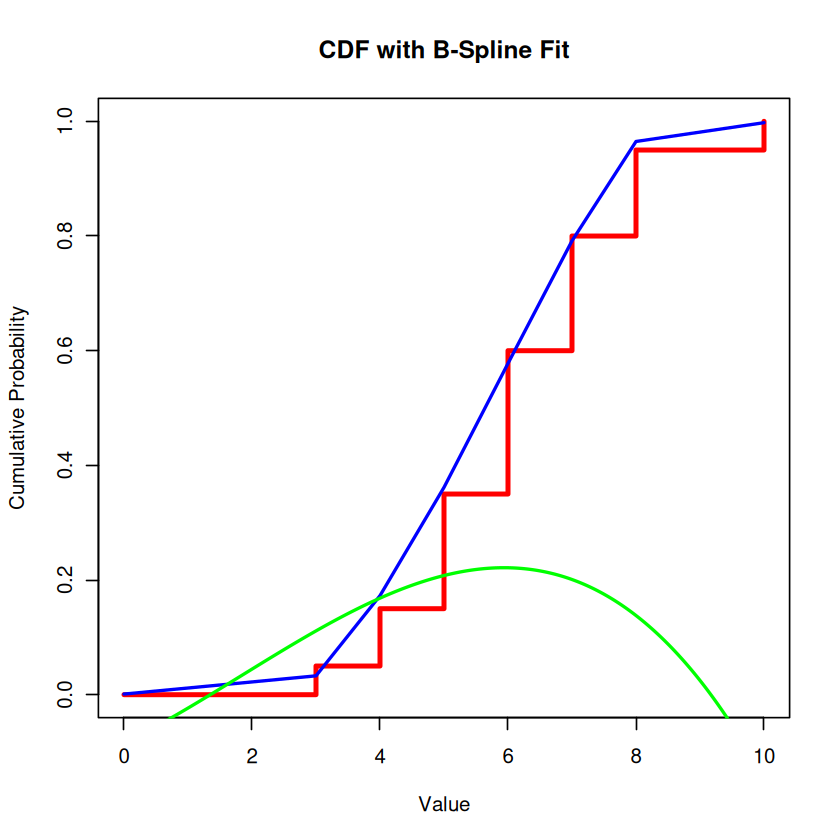

In [67]:
# Values representing the bin edges (right edges of bins)
vals <- c(3, 4, 5, 6, 7, 8)

# Cumulative probabilities for these bins
cumsums <- c(0.05, 0.15, 0.35, 0.6, 0.8, 0.95)

# Define the limits
lower_limit <- 0
upper_limit <- 10

# Adjust the cumulative probabilities to account for the limits
# Include the lower and upper limits, and set the corresponding cumulative probabilities to 0 and 1 respectively
extended_vals <- c(lower_limit, vals, upper_limit)
extended_cumsums <- c(0, cumsums, 1)

# Fit the B-spline to the extended CDF data (force the spline to meet at limits)
cdf_bspline_fit <- lm(extended_cumsums ~ bSpline(extended_vals, degree = 4))

# Show the summary of the fitted B-spline model
summary(cdf_bspline_fit)

# Create the plot for cumulative distribution function
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 3, 
     xlim = c(lower_limit, upper_limit), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")

# Add the B-spline fit to the plot
lines(extended_vals, predict(cdf_bspline_fit), col = "blue", lwd = 2)

# Step 1: Predict the CDF over a finely grained sequence
extended_vals_full <- seq(lower_limit, upper_limit, length.out = 500)  # Extended range

cdf_bspline_fit_values <- predict(cdf_bspline_fit, newdata = data.frame(extended_vals = extended_vals_full))

# Step 2: Calculate the derivative to get the PDF
cdf_bspline_derivative_full <- diff(cdf_bspline_fit_values) / diff(extended_vals_full)

# Step 3: Normalize the PDF (integrate to 1)
pdf_integral <- sum(cdf_bspline_derivative_full) * diff(extended_vals_full[1:2])  # Approximate integral
cdf_bspline_derivative_normalized <- cdf_bspline_derivative_full / pdf_integral  # Normalize

# Step 4: Plot the normalized PDF (derived from the derivative)
lines(extended_vals_full[-length(extended_vals_full)], cdf_bspline_derivative_normalized, col = "green", lwd = 2)

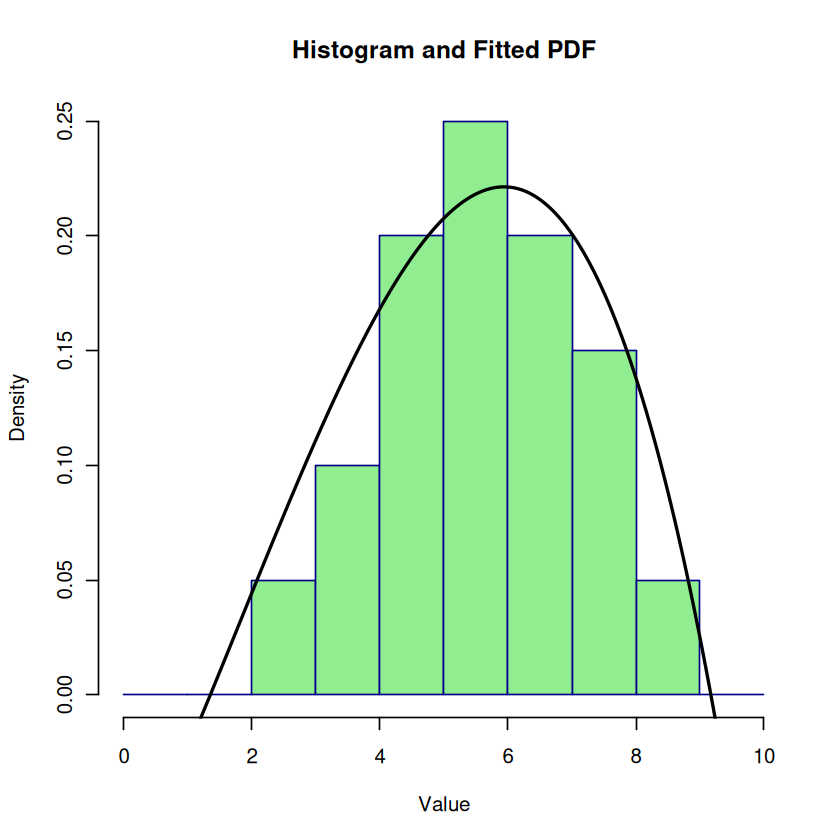

In [70]:
# Step 1: Plot the histogram with density on the y-axis
hist(data, prob = TRUE, col = "lightgreen", border = "darkblue", 
     xlim = c(lower_limit, upper_limit), 
     xlab = "Value", ylab = "Density", 
     main = "Histogram and Fitted PDF", 
     breaks = seq(lower_limit, upper_limit, by = 1),ylim=c(0,0.25))

# Step 4: Plot the normalized PDF (derived from the derivative)
lines(extended_vals_full[-length(extended_vals_full)], cdf_bspline_derivative_normalized, col = "black", lwd = 2)


Call:
lm(formula = extended_cumsums ~ bSpline(extended_vals, degree = 4))

Residuals:
        1         2         3         4         5         6         7         8 
-0.001068  0.017157 -0.022707 -0.011559  0.022235  0.008475 -0.014874  0.002341 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          0.001068   0.024059   0.044  0.96737    
bSpline(extended_vals, degree = 4)1 -0.211822   0.142239  -1.489  0.23319    
bSpline(extended_vals, degree = 4)2  0.031067   0.178593   0.174  0.87298    
bSpline(extended_vals, degree = 4)3  1.358038   0.107667  12.613  0.00107 ** 
bSpline(extended_vals, degree = 4)4  0.996591   0.033966  29.341 8.69e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02407 on 3 degrees of freedom
Multiple R-squared:  0.9985,	Adjusted R-squared:  0.9965 
F-statistic: 495.1 on 4 and 3 DF,  p-value: 0.0001469


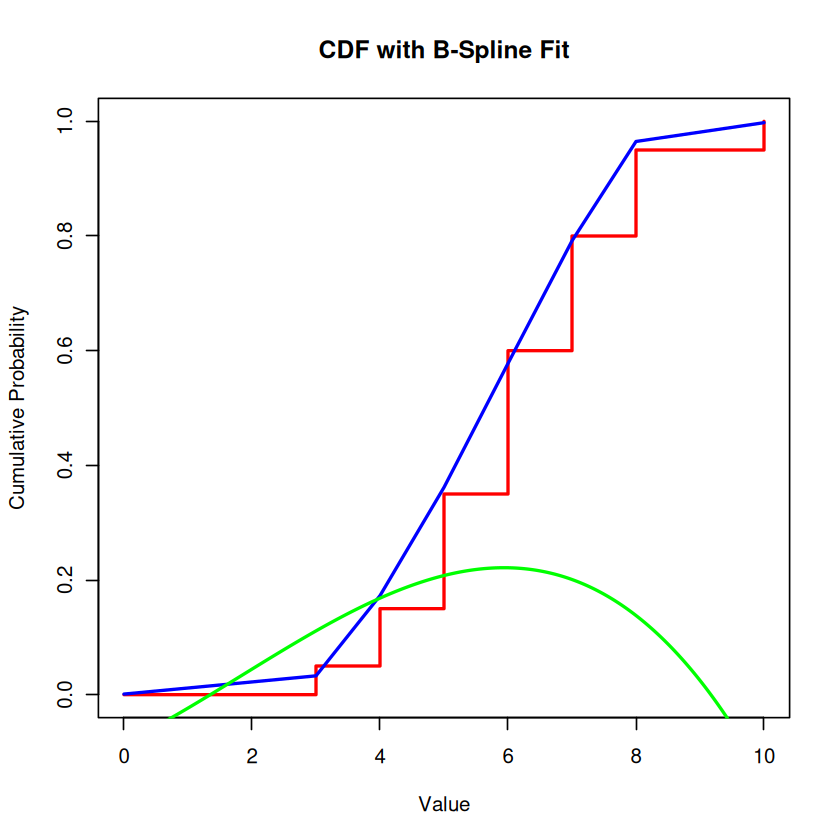

In [73]:
# Values representing the bin edges (right edges of bins)
vals <- c(3, 4, 5, 6, 7, 8)

# Cumulative probabilities for these bins
cumsums <- c(0.05, 0.15, 0.35, 0.6, 0.8, 0.95)

# Define the limits
lower_limit <- 0
upper_limit <- 10

# Adjust the cumulative probabilities to account for the limits
# Include the lower and upper limits, and set the corresponding cumulative probabilities to 0 and 1 respectively
extended_vals <- c(lower_limit, vals, upper_limit)
extended_cumsums <- c(0, cumsums, 1)

# Fit the B-spline to the extended CDF data (force the spline to meet at limits)
cdf_bspline_fit <- lm(extended_cumsums ~ bSpline(extended_vals, degree = 4))

# Show the summary of the fitted B-spline model
summary(cdf_bspline_fit)

# Create the plot for cumulative distribution function
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 2, 
     xlim = c(lower_limit, upper_limit), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")

# Add the B-spline fit to the plot
lines(extended_vals, predict(cdf_bspline_fit), col = "blue", lwd = 2)

# Step 1: Predict the CDF over a finely grained sequence
extended_vals_full <- seq(lower_limit, upper_limit, length.out = 500)  # Extended range

cdf_bspline_fit_values <- predict(cdf_bspline_fit, newdata = data.frame(extended_vals = extended_vals_full))

# Step 2: Calculate the derivative to get the PDF
cdf_bspline_derivative_full <- diff(cdf_bspline_fit_values) / diff(extended_vals_full)

# Step 3: Normalize the PDF (integrate to 1)
pdf_integral <- sum(cdf_bspline_derivative_full) * diff(extended_vals_full[1:2])  # Approximate integral
cdf_bspline_derivative_normalized <- cdf_bspline_derivative_full / pdf_integral  # Normalize

# Step 4: Plot the normalized PDF (derived from the derivative)
lines(extended_vals_full[-length(extended_vals_full)], cdf_bspline_derivative_normalized, col = "green", lwd = 2)

In [74]:
# Manually compute the integral using the trapezoidal rule
integral_check <- sum(0.5 * (cdf_bspline_derivative_normalized[-length(extended_vals_full)] + cdf_bspline_derivative_normalized[-1]) * diff(extended_vals_full))

# Print the result
print(integral_check)

Warning message in cdf_bspline_derivative_normalized[-length(extended_vals_full)] + :
“longer object length is not a multiple of shorter object length”


[1] 1.000011


In [52]:
# Numerical integration of the PDF to check if it integrates to 1
pdf_integral <- sum(cdf_bspline_derivative) * diff(extended_vals)[1]  # Approximate integral using the trapezoidal rule

# Check if it is approximately 1
pdf_integral

[1] 2.894619

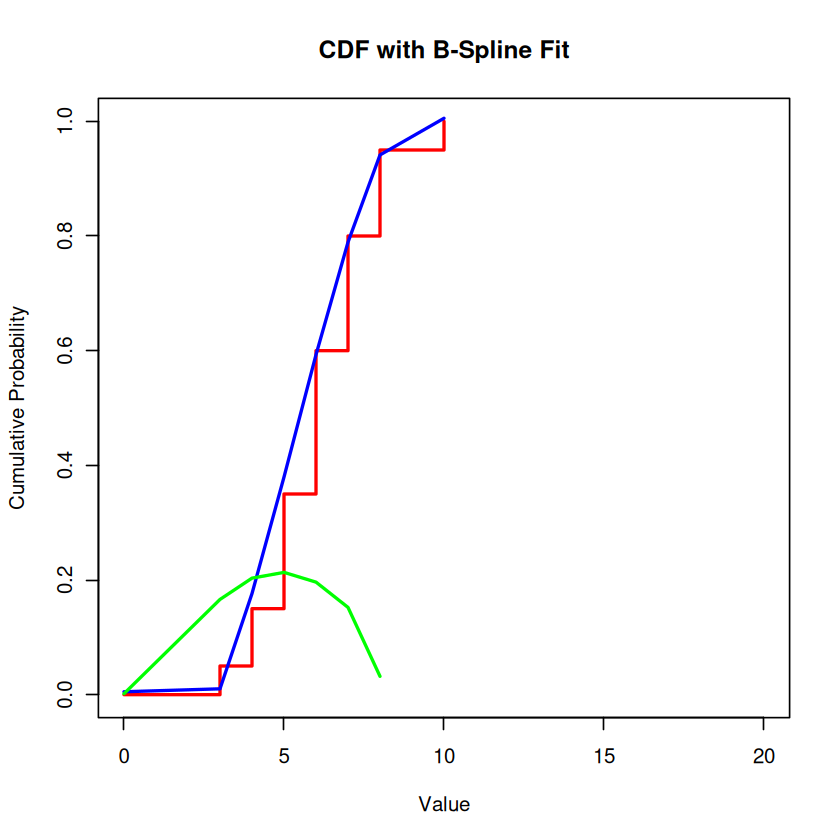

In [49]:
# Create the plot for cumulative distribution function
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 2, 
     xlim = c(0, 20), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")
  
# Add the B-spline fit to the plot
lines(extended_vals, predict(cdf_bspline_fit), col = "blue", lwd = 2)

# Optionally, plot the derivative to see the PDF
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit)) / diff(extended_vals)
lines(extended_vals[-length(extended_vals)], cdf_bspline_derivative, col = "green", lwd = 2)

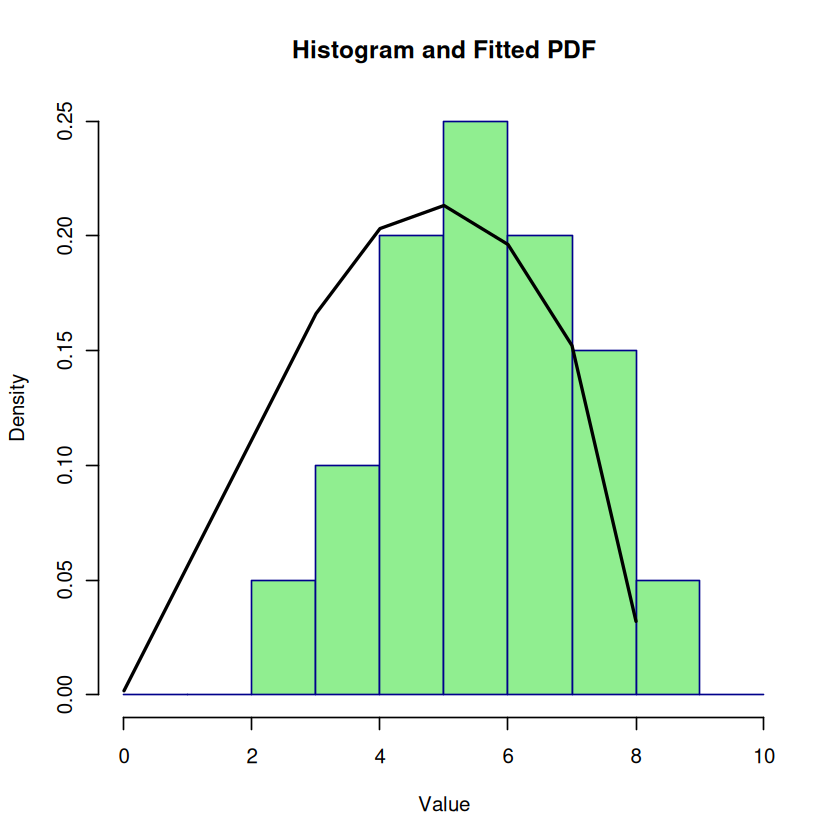

In [50]:
# Step 1: Plot the histogram with density on the y-axis
hist(data, prob = TRUE, col = "lightgreen", border = "darkblue", 
     xlim = c(lower_limit, upper_limit), 
     xlab = "Value", ylab = "Density", 
     main = "Histogram and Fitted PDF", 
     breaks = seq(lower_limit, upper_limit, by = 1))

# Step 2: Overlay the green line (the PDF derived from the spline)
# Ensure the PDF line is scaled appropriately
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit)) / diff(extended_vals)
lines(extended_vals[-length(extended_vals)], cdf_bspline_derivative, col = "black", lwd = 2)


Call:
lm(formula = extended_cumsums ~ bSpline(extended_vals, degree = 3))

Residuals:
        1         2         3         4         5         6         7         8 
-0.005079  0.039795 -0.026340 -0.029586  0.007117  0.010831  0.008616 -0.005354 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          0.005079   0.029217   0.174   0.8704    
bSpline(extended_vals, degree = 3)1 -0.585778   0.084812  -6.907   0.0023 ** 
bSpline(extended_vals, degree = 3)2  1.251039   0.070096  17.847 5.79e-05 ***
bSpline(extended_vals, degree = 3)3  1.000275   0.041362  24.184 1.73e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02937 on 4 degrees of freedom
Multiple R-squared:  0.997,	Adjusted R-squared:  0.9947 
F-statistic: 442.7 on 3 and 4 DF,  p-value: 1.689e-05


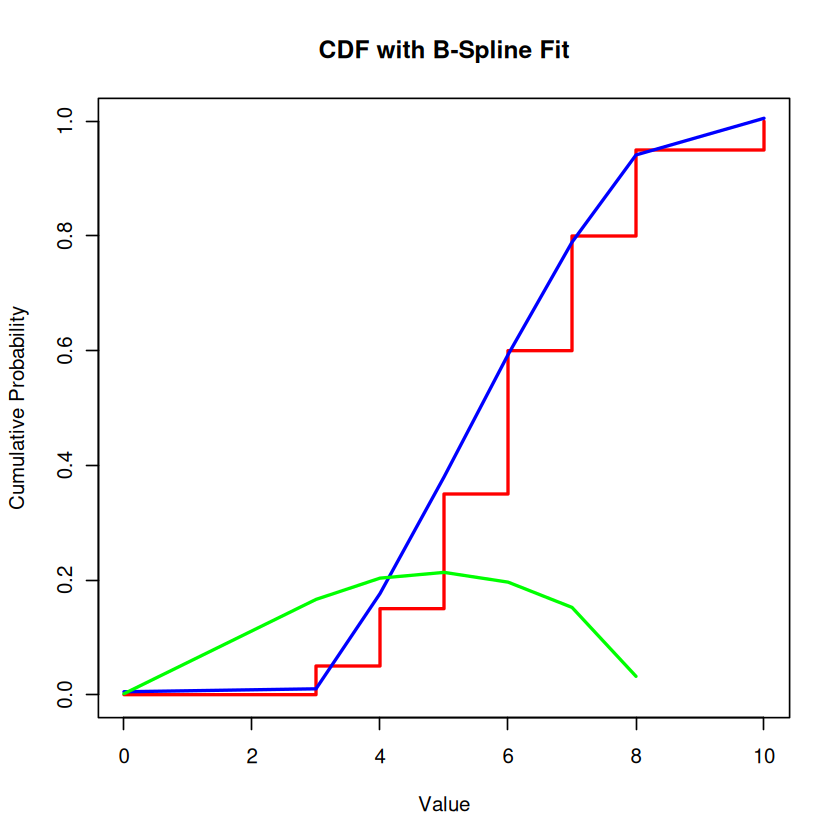

In [44]:
# Define the limits
lower_limit <- 0
upper_limit <- 10

# Adjust the cumulative probabilities to account for the limits
# Include the lower and upper limits, and set the corresponding cumulative probabilities to 0 and 1 respectively
extended_vals <- c(lower_limit, vals, upper_limit)
extended_cumsums <- c(0, cumsums, 1)

# Fit the B-spline to the extended CDF data (force the spline to meet at limits)
cdf_bspline_fit <- lm(extended_cumsums ~ bSpline(extended_vals, degree = 3))

# Show the summary of the fitted B-spline model
summary(cdf_bspline_fit)

# Create the plot for cumulative distribution function
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 2, 
     xlim = c(lower_limit, upper_limit), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")

# Add the B-spline fit to the plot
lines(extended_vals, predict(cdf_bspline_fit), col = "blue", lwd = 2)

# Optionally, plot the derivative to see the PDF
# Calculate the derivative of the fitted CDF (PDF)
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit)) / diff(extended_vals)

# Plot the PDF derived from the derivative, making sure we align it with the original bins
lines(extended_vals[-length(extended_vals)], cdf_bspline_derivative, col = "green", lwd = 2)

In [34]:
# Show summary of the fitted model
summary(cdf_bspline_fit)


Call:
lm(formula = extended_cumsums ~ bSpline(extended_vals, degree = 3))

Residuals:
        1         2         3         4         5         6         7         8 
-0.005079  0.039795 -0.026340 -0.029586  0.007117  0.010831  0.008616 -0.005354 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          0.005079   0.029217   0.174   0.8704    
bSpline(extended_vals, degree = 3)1 -0.585778   0.084812  -6.907   0.0023 ** 
bSpline(extended_vals, degree = 3)2  1.251039   0.070096  17.847 5.79e-05 ***
bSpline(extended_vals, degree = 3)3  1.000275   0.041362  24.184 1.73e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02937 on 4 degrees of freedom
Multiple R-squared:  0.997,	Adjusted R-squared:  0.9947 
F-statistic: 442.7 on 3 and 4 DF,  p-value: 1.689e-05


ERROR: Error in barplot.default(pdf_vals, names.arg = vals[-length(vals)], col = "lightgreen", : incorrect number of names


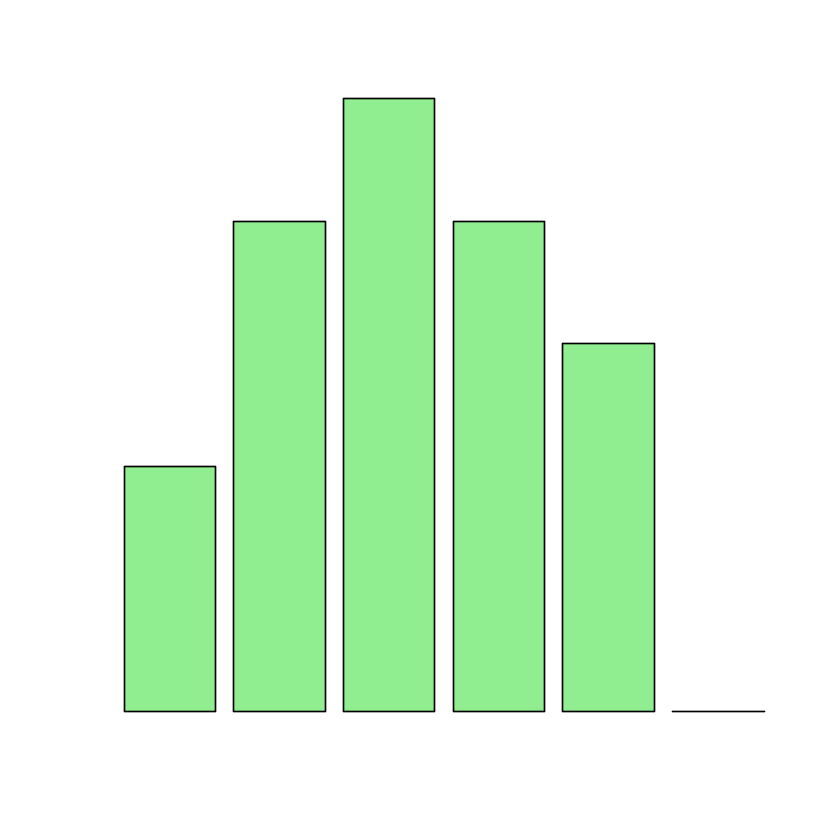

In [13]:
# Example values and cumulative sums
vals <- c(3, 4, 5, 6, 7, 8)
cumsums <- c(0.05, 0.15, 0.35, 0.6, 0.8, 0.95)

# Calculate PDF (difference in CDF divided by bin width)
pdf_vals <- diff(cumsums) / diff(vals)  # PDF = change in CDF / change in value

# Add a 0 for the last value (no change in probability beyond last bin)
pdf_vals <- c(pdf_vals, 0) 

# Plot the PDF as a histogram
barplot(pdf_vals, names.arg = vals[-length(vals)], 
        col = "lightgreen", xlab = "Value", 
        ylab = "Probability Density", 
        main = "PDF from Histogram Data")

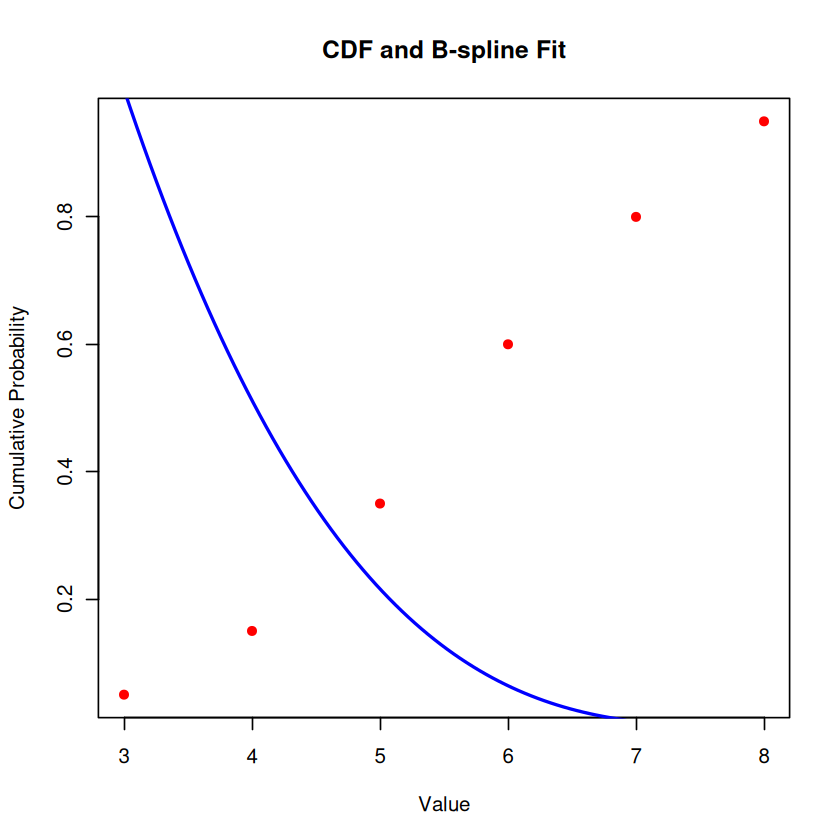

In [7]:
# Create a finer grid of points from the minimum to the maximum of your vals
finer_vals <- seq(min(vals), max(vals), length.out = 100)

# Use the finer grid to predict the CDF values
cdf_bspline_values_finer <- predict(cdf_bspline_fit, x = finer_vals)[, 1]

# Plot the original CDF and the B-spline fit
plot(vals, cumsums, col = "red", pch = 16, xlab = "Value", ylab = "Cumulative Probability",
     main = "CDF and B-spline Fit")

# Now add the smoothed B-spline fit to the plot using the finer grid
lines(finer_vals, cdf_bspline_values_finer, col = "blue", lwd = 2)